# Chuẩn hóa dữ liệu VG Sales

## Mục lục
1. Chọn dataset
2. Dataset có gì
3. Đánh giá vấn đề
4. Đưa ra giải pháp
5. Kiểm chứng

In [1]:
# Cài đặt các thư viện cần thiết (chỉ cần chạy 1 lần)
%pip install pandas numpy matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Program Files\Python311\python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Đọc dữ liệu
df = pd.read_csv("vgsales.csv")
print(f"Kích thước: {df.shape[0]} dòng x {df.shape[1]} cột")
df.head()

Kích thước: 16598 dòng x 11 cột


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## 1. Chọn Dataset

- **Tên:** Video Game Sales
- **Nguồn:** Kaggle
- **Mô tả:** Dữ liệu doanh số các game trên toàn thế giới
- **Số dòng:** ~16,598
- **Số cột:** 11

## 2. Dataset có gì?

In [3]:
print("=== Tên cột và kiểu dữ liệu ===")
print(df.dtypes)
print("\n=== Thông tin tổng quan ===")
df.info()

=== Tên cột và kiểu dữ liệu ===
Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

=== Thông tin tổng quan ===
<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtyp

In [4]:
print("=== 5 dòng đầu ===")
display(df.head())
print("\n=== 5 dòng cuối ===")
display(df.tail())

=== 5 dòng đầu ===


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37



=== 5 dòng cuối ===


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002.0,Platform,Kemco,0.01,0.00,0.0,0.0,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003.0,Shooter,Infogrames,0.01,0.00,0.0,0.0,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008.0,Racing,Activision,0.00,0.00,0.0,0.0,0.01
16596,16599,Know How 2,DS,2010.0,Puzzle,7G//AMES,0.00,0.01,0.0,0.0,0.01
16597,16600,Spirits & Spells,GBA,2003.0,Platform,Wanadoo,0.01,0.00,0.0,0.0,0.01


In [5]:
print("=== Giá trị thiếu ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Số thiếu': missing, 'Tỷ lệ %': missing_pct.round(2)})
display(missing_df)

=== Giá trị thiếu ===


,Số thiếu,Tỷ lệ %
Rank,0,0.00
Name,0,0.00
Platform,0,0.00
Year,271,1.63
Genre,0,0.00
Publisher,58,0.35
NA_Sales,0,0.00
EU_Sales,0,0.00
JP_Sales,0,0.00
Other_Sales,0,0.00


In [7]:
print("=== Dòng trùng lặp ===")
print(f"Dòng trùng hoàn toàn: {df.duplicated().sum()}")
print(f"Tên game trùng: {df['Name'].duplicated().sum()}")

print("\n=== Số lượng unique values ===")
for col in df.columns:
    print(f"{col}: {df[col].nunique()}")

=== Dòng trùng lặp ===
Dòng trùng hoàn toàn: 0
Tên game trùng: 5105

=== Số lượng unique values ===
Rank: 16598
Name: 11493
Platform: 31
Year: 39
Genre: 12
Publisher: 578
NA_Sales: 409
EU_Sales: 305
JP_Sales: 244
Other_Sales: 157
Global_Sales: 623


## 3. Đánh giá vấn đề

In [8]:
print("=== Vấn đề 1: Year có giá trị NaN hoặc ngoài phạm vi ===")
print(f"Year NaN: {df['Year'].isna().sum()}")
print(f"Year range: {df['Year'].min()} - {df['Year'].max()}")
invalid_year = df[(df['Year'] < 1980) | (df['Year'] > 2025)]
print(f"Year ngoài [1980, 2025]: {len(invalid_year)}")
if len(invalid_year) > 0:
    display(invalid_year.head())

=== Vấn đề 1: Year có giá trị NaN hoặc ngoài phạm vi ===
Year NaN: 271
Year range: 1980.0 - 2020.0
Year ngoài [1980, 2025]: 0


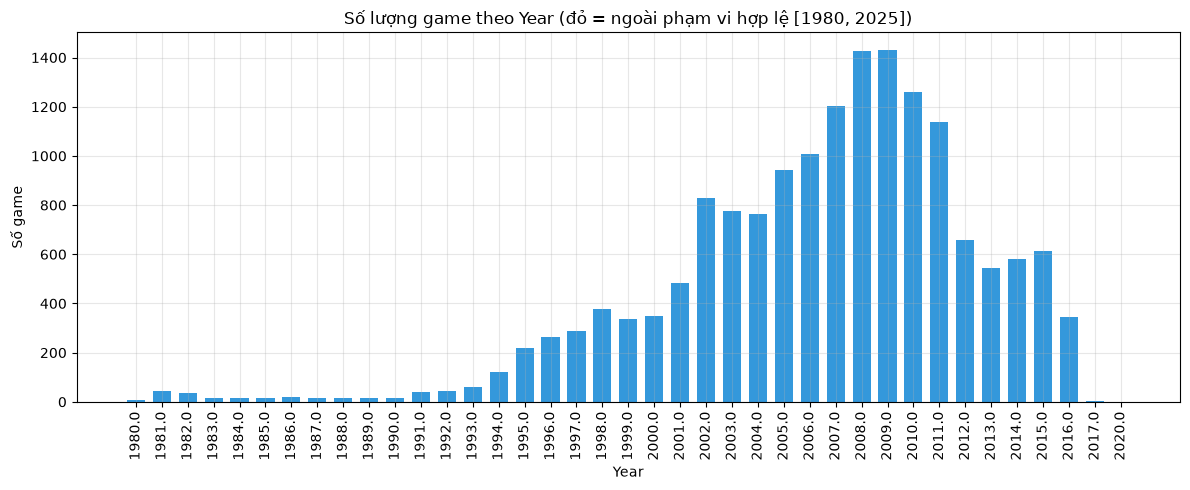

In [9]:
# Biểu đồ cột: phân bố số game theo Year (làm nổi bật vùng ngoài [1980, 2025])
year_counts = df['Year'].value_counts().sort_index()
colors = ['#e74c3c' if (y < 1980 or y > 2025) else '#3498db' for y in year_counts.index]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(year_counts.index.astype(str), year_counts.values, color=colors, width=0.7)
ax.set_title('Số lượng game theo Year (đỏ = ngoài phạm vi hợp lệ [1980, 2025])')
ax.set_xlabel('Year')
ax.set_ylabel('Số game')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [10]:
print("=== Vấn đề 2: Publisher có giá trị thiếu ===")
print(f"Publisher NaN: {df['Publisher'].isna().sum()}")

print("\n=== Vấn đề 3: Cột Sales có giá trị âm ===")
for col in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']:
    neg_count = (df[col] < 0).sum()
    print(f"{col} < 0: {neg_count}")

print("\n=== Vấn đề 4: Rank bị trùng hoặc thiếu ===")
print(f"Rank trùng: {df['Rank'].duplicated().sum()}")
print(f"Rank thiếu: {df['Rank'].isna().sum()}")

=== Vấn đề 2: Publisher có giá trị thiếu ===
Publisher NaN: 58

=== Vấn đề 3: Cột Sales có giá trị âm ===
NA_Sales < 0: 0
EU_Sales < 0: 0
JP_Sales < 0: 0
Other_Sales < 0: 0
Global_Sales < 0: 0

=== Vấn đề 4: Rank bị trùng hoặc thiếu ===
Rank trùng: 0
Rank thiếu: 0


In [12]:
print("=== Vấn đề 5: Name có giá trị trùng (cùng game, khác platform) ===")
dup_names = df.groupby('Name').size().sort_values(ascending=False)
print(f"Tổng số game trùng tên: {(dup_names > 1).sum()}")
print("\nTop 5 game xuất hiện nhiều nhất:")
print(dup_names.head(10))

print("\n=== Vấn đề 6: Platform và Genre ===")
print(f"Số Platform unique: {df['Platform'].nunique()}")
print(f"Số Genre unique: {df['Genre'].nunique()}")
print(f"\nPlatforms: {sorted(df['Platform'].unique())}")
print(f"\nGenres: {sorted(df['Genre'].unique())}")

=== Vấn đề 5: Name có giá trị trùng (cùng game, khác platform) ===
Tổng số game trùng tên: 2775

Top 5 game xuất hiện nhiều nhất:
Name
Need for Speed: Most Wanted                12
LEGO Marvel Super Heroes                    9
Madden NFL 07                               9
Ratatouille                                 9
FIFA 14                                     9
Lego Batman 3: Beyond Gotham                8
LEGO Jurassic World                         8
LEGO Star Wars II: The Original Trilogy     8
Cars                                        8
Angry Birds Star Wars                       8
dtype: int64

=== Vấn đề 6: Platform và Genre ===
Số Platform unique: 31
Số Genre unique: 12

Platforms: ['2600', '3DO', '3DS', 'DC', 'DS', 'GB', 'GBA', 'GC', 'GEN', 'GG', 'N64', 'NES', 'NG', 'PC', 'PCFX', 'PS', 'PS2', 'PS3', 'PS4', 'PSP', 'PSV', 'SAT', 'SCD', 'SNES', 'TG16', 'WS', 'Wii', 'WiiU', 'X360', 'XB', 'XOne']

Genres: ['Action', 'Adventure', 'Fighting', 'Misc', 'Platform', 'Puzzle', 'Racing', 

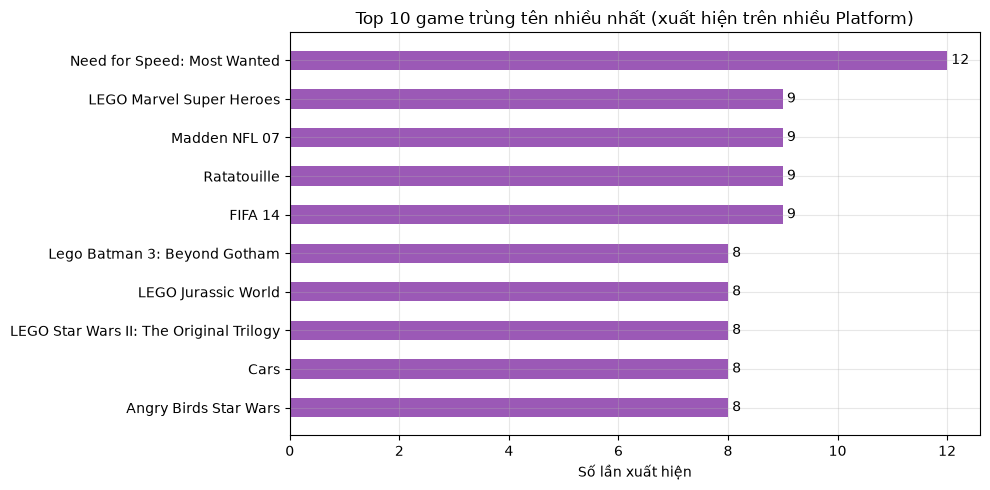

In [13]:
# Biểu đồ cột: Top 10 game trùng tên nhiều nhất
top_dup = dup_names.head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_dup.index[::-1], top_dup.values[::-1], color='#9b59b6', height=0.5)
ax.set_title('Top 10 game trùng tên nhiều nhất (xuất hiện trên nhiều Platform)')
ax.set_xlabel('Số lần xuất hiện')
ax.bar_label(bars, padding=3)
plt.tight_layout()
plt.show()

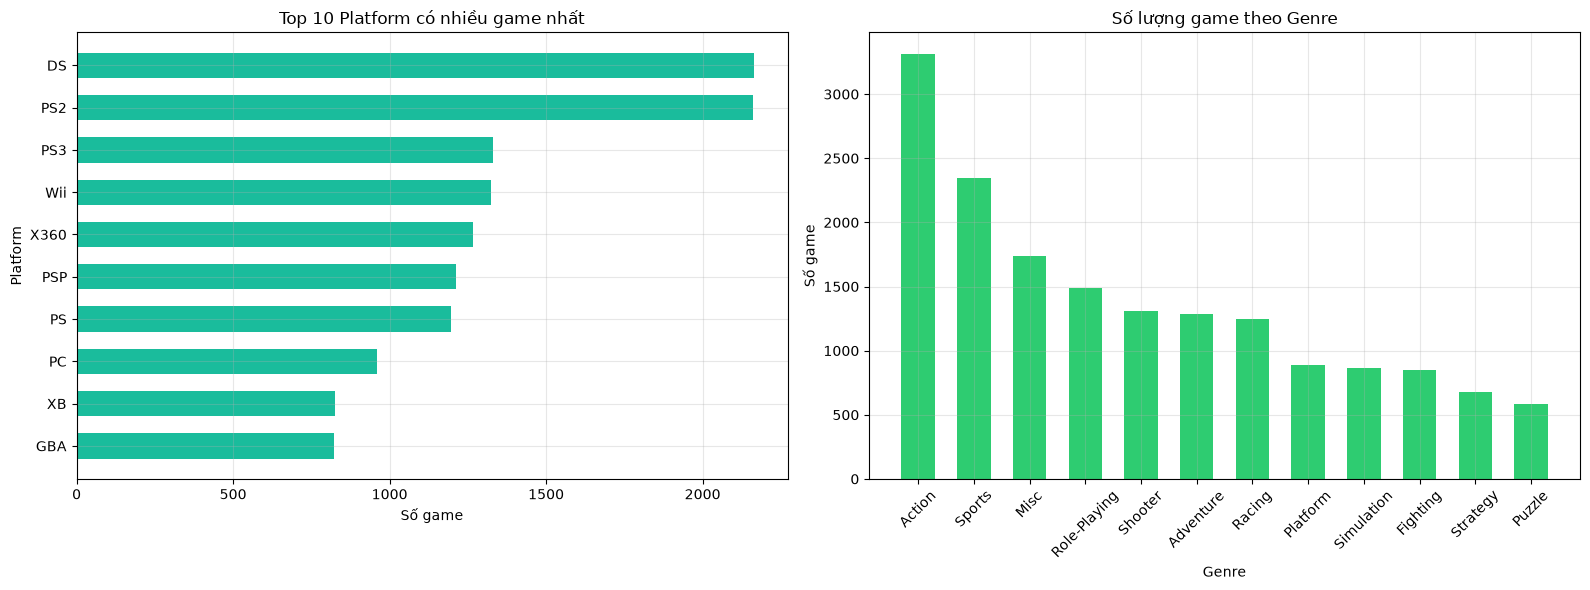

In [30]:
# Biểu đồ cột: số lượng game theo Platform và theo Genre
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

platform_counts = df['Platform'].value_counts().head(10)

axes[0].barh(platform_counts.index[::-1], platform_counts.values[::-1], color='#1abc9c', height=0.6)
axes[0].set_title('Top 10 Platform có nhiều game nhất')
axes[0].set_xlabel('Số game')
axes[0].set_ylabel('Platform')
axes[0].tick_params(axis='x')

genre_counts = df['Genre'].value_counts()
axes[1].bar(genre_counts.index, genre_counts.values, color='#2ecc71', width=0.6)
axes[1].set_title('Số lượng game theo Genre')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('Số game')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 4. Giải pháp

In [15]:
# Tạo bản sao để xử lý
df_clean = df.copy()
print(f"Trước clean: {df_clean.shape}")

Trước clean: (16598, 11)


In [16]:
# 4.1: Xóa dòng trùng lặp hoàn toàn
df_clean = df_clean.drop_duplicates()
print(f"Sau xóa trùng: {df_clean.shape}")

Sau xóa trùng: (16598, 11)


In [17]:
# 4.2: Xử lý Year - điền NaN bằng giá trị phổ biến nhất
year_mode = df_clean['Year'].mode()[0]
print(f"Year mode: {year_mode}")
df_clean['Year'] = df_clean['Year'].fillna(year_mode).astype(int)

# Xóa dòng Year ngoài phạm vi hợp lý [1980, 2020]
invalid_year_mask = (df_clean['Year'] < 1980) | (df_clean['Year'] > 2020)
print(f"Year ngoài [1980, 2020]: {invalid_year_mask.sum()}")
df_clean = df_clean[~invalid_year_mask]

Year mode: 2009.0
Year ngoài [1980, 2020]: 0


In [18]:
# 4.3: Xử lý Publisher - điền NaN bằng 'Unknown'
df_clean['Publisher'] = df_clean['Publisher'].fillna('Unknown')
print(f"Publisher NaN còn lại: {df_clean['Publisher'].isna().sum()}")

Publisher NaN còn lại: 0


In [19]:
# 4.4: Kiểm tra và xóa dòng có Sales âm
for col in ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']:
    neg_mask = df_clean[col] < 0
    if neg_mask.sum() > 0:
        print(f"Xóa {neg_mask.sum()} dòng có {col} < 0")
        df_clean = df_clean[~neg_mask]

In [20]:
# 4.5: Sửa lại Rank sau khi xóa dòng
df_clean = df_clean.sort_values('Global_Sales', ascending=False).reset_index(drop=True)
df_clean['Rank'] = range(1, len(df_clean) + 1)
print(f"Rank mới: 1 đến {df_clean['Rank'].max()}")

Rank mới: 1 đến 16598


In [21]:
# 4.6: Chuẩn hóa chuỗi (xóa khoảng trắng thừa)
for col in df_clean.select_dtypes(include=['object', 'str']).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# 4.7: Làm tròn cột Sales
sales_cols = ['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']
df_clean[sales_cols] = df_clean[sales_cols].round(2)

print(f"\nKích thước sau clean: {df_clean.shape}")


Kích thước sau clean: (16598, 11)


## 5. Kiểm chứng

In [22]:
print("=== KIỂM CHỨNG SAU CLEAN ===")

# 5.1: Không còn dòng trùng
print(f"\n1. Dòng trùng hoàn toàn: {df_clean.duplicated().sum()} (yêu cầu: 0)")

# 5.2: Year không còn NaN, trong phạm vi [1980, 2020]
print(f"2. Year NaN: {df_clean['Year'].isna().sum()}")
print(f"   Year range: [{df_clean['Year'].min()}, {df_clean['Year'].max()}]")

# 5.3: Publisher không còn NaN
print(f"3. Publisher NaN: {df_clean['Publisher'].isna().sum()}")

# 5.4: Sales không còn âm
for col in sales_cols:
    neg_count = (df_clean[col] < 0).sum()
    print(f"4. {col} < 0: {neg_count}")

=== KIỂM CHỨNG SAU CLEAN ===

1. Dòng trùng hoàn toàn: 0 (yêu cầu: 0)
2. Year NaN: 0
   Year range: [1980, 2020]
3. Publisher NaN: 0
4. NA_Sales < 0: 0
4. EU_Sales < 0: 0
4. JP_Sales < 0: 0
4. Other_Sales < 0: 0
4. Global_Sales < 0: 0


In [23]:
# 5.5: Rank liên tục từ 1
print(f"5. Rank: {df_clean['Rank'].min()} đến {df_clean['Rank'].max()}, liên tục: {df_clean['Rank'].nunique() == len(df_clean)}")

# 5.6: Kiểm tra Global_Sales = tổng các cột khác
df_clean['Calc_Global'] = df_clean[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']].sum(axis=1).round(2)
match = (df_clean['Calc_Global'] == df_clean['Global_Sales']).sum()
print(f"6. Global_Sales = NA+EU+JP+Other: {match}/{len(df_clean)} khớp")
df_clean = df_clean.drop('Calc_Global', axis=1)

5. Rank: 1 đến 16598, liên tục: True
6. Global_Sales = NA+EU+JP+Other: 12087/16598 khớp


In [24]:
print("=== Giá trị thiếu còn lại ===")
missing_final = df_clean.isnull().sum()
print(missing_final[missing_final > 0] if missing_final.sum() > 0 else "Không có giá trị thiếu!")

=== Giá trị thiếu còn lại ===
Không có giá trị thiếu!


In [25]:
# 5.7: So sánh trước/sau
print("=== SO SÁNH TRƯỚC/SAU ===")
print(f"{'Chỉ số':<25}{'Trước':>15}{'Sau':>15}")
print("-" * 55)
print(f"{'Số dòng':<25}{len(df):>15}{len(df_clean):>15}")
print(f"{'Dòng trùng':<25}{df.duplicated().sum():>15}{df_clean.duplicated().sum():>15}")
print(f"{'Year NaN':<25}{df['Year'].isna().sum():>15}{df_clean['Year'].isna().sum():>15}")
print(f"{'Publisher NaN':<25}{df['Publisher'].isna().sum():>15}{df_clean['Publisher'].isna().sum():>15}")

=== SO SÁNH TRƯỚC/SAU ===
Chỉ số                             Trước            Sau
-------------------------------------------------------
Số dòng                            16598          16598
Dòng trùng                             0              0
Year NaN                             271              0
Publisher NaN                         58              0


In [27]:
# Lưu file đã clean
df_clean.to_csv("vgsales_cleaned.csv", index=False)
print("✅ Đã lưu: vgsales_cleaned.csv")
display(df_clean.head(10))

✅ Đã lưu: vgsales_cleaned.csv


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
5,6,Tetris,GB,1989,Puzzle,Nintendo,23.20,2.26,4.22,0.58,30.26
6,7,New Super Mario Bros.,DS,2006,Platform,Nintendo,11.38,9.23,6.50,2.90,30.01
7,8,Wii Play,Wii,2006,Misc,Nintendo,14.03,9.20,2.93,2.85,29.02
8,9,New Super Mario Bros. Wii,Wii,2009,Platform,Nintendo,14.59,7.06,4.70,2.26,28.62
9,10,Duck Hunt,NES,1984,Shooter,Nintendo,26.93,0.63,0.28,0.47,28.31
